In [82]:
import pandas as pd
import matplotlib.pyplot as plt

In [83]:
df = pd.read_csv("../outputs/figures/predictions/global/nn_predictions_global.csv")

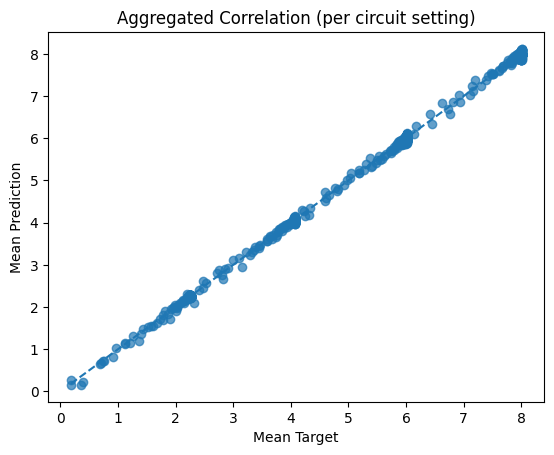

In [84]:
# aggregate over seeds
agg = df.groupby(["family", "n_qubits", "n_layers"]).mean(numeric_only=True).reset_index()

plt.figure()
plt.scatter(agg["target"], agg["prediction"], alpha=0.7)

min_val = agg["target"].min()
max_val = agg["target"].max()
plt.plot([min_val, max_val], [min_val, max_val], "--")

plt.xlabel("Mean Target")
plt.ylabel("Mean Prediction")
plt.title("Aggregated Correlation (per circuit setting)")
plt.show()

In [63]:
cleaned_df = df.dropna(subset=["target", "prediction"])
grouped = cleaned_df.groupby(["family", "n_qubits", "n_layers"])

results = grouped.apply(
    lambda g: g["target"].corr(g["prediction"])
).reset_index(name="corr")

c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Victor\Desktop\Université\Research\qml-quansistor-entropy\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [64]:
results

,family,n_qubits,n_layers,corr
0,clifford,tensor([10]),tensor([100]),0.063618
1,clifford,tensor([10]),tensor([10]),NaN
2,clifford,tensor([10]),tensor([12]),0.285838
3,clifford,tensor([10]),tensor([14]),0.569993
4,clifford,tensor([10]),tensor([16]),0.772468
...,...,...,...,...
795,random,tensor([8]),tensor([90]),-0.029287
796,random,tensor([8]),tensor([92]),0.102895
797,random,tensor([8]),tensor([94]),0.034578
798,random,tensor([8]),tensor([96]),0.029918


In [65]:
agg = cleaned_df.groupby(["family", "n_qubits", "n_layers"]).agg({
    "target": "mean",
    "prediction": "mean",
}).reset_index()

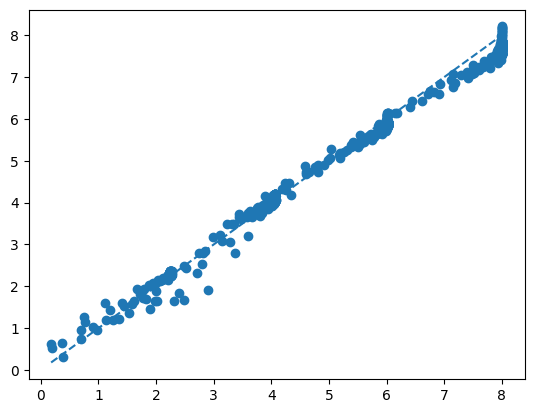

In [66]:
plt.scatter(agg["target"], agg["prediction"])
plt.plot([agg["target"].min(), agg["target"].max()],
         [agg["target"].min(), agg["target"].max()],
         "--")

Text(0, 0.5, 'Absolute Error')

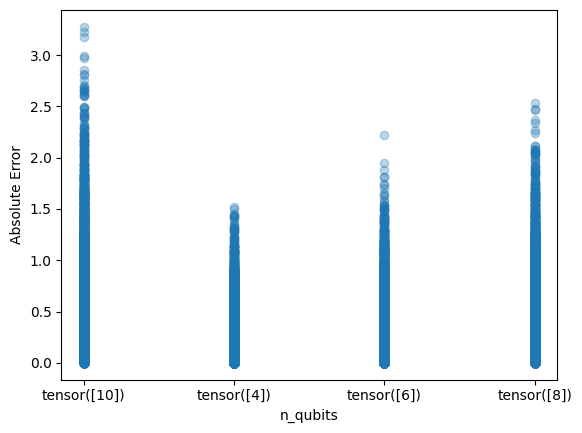

In [67]:
cleaned_df["abs_error"] = (cleaned_df["prediction"] - cleaned_df["target"]).abs()

plt.scatter(cleaned_df["n_qubits"], cleaned_df["abs_error"], alpha=0.3)
plt.xlabel("n_qubits")
plt.ylabel("Absolute Error")

In [68]:
family_df = df.groupby("family").apply(lambda x: x.sample(100))

In [69]:
print(family_df)

                                          cid                  seed  \
family                                                                
clifford 59059    clifford_Q8_L38_S1708655365  tensor([1708655365])   
         13772   clifford_Q12_L74_S2817257749  tensor([2817257749])   
         16057   clifford_Q16_L10_S3674987492  tensor([3674987492])   
         30563    clifford_Q4_L12_S1954469248  tensor([1954469248])   
         25142    clifford_Q26_L2_S1677667565  tensor([1677667565])   
...                                       ...                   ...   
random   219862     random_Q16_L78_S420583601   tensor([420583601])   
         254041      random_Q6_L74_S166367410   tensor([166367410])   
         215181    random_Q12_L18_S1804889825  tensor([1804889825])   
         262351     random_Q8_L44_S2567640914  tensor([2567640914])   
         204524    random_Q10_L24_S1385843082  tensor([1385843082])   

                     n_qubits      n_layers    target  prediction  error  
f

In [70]:
df = family_df

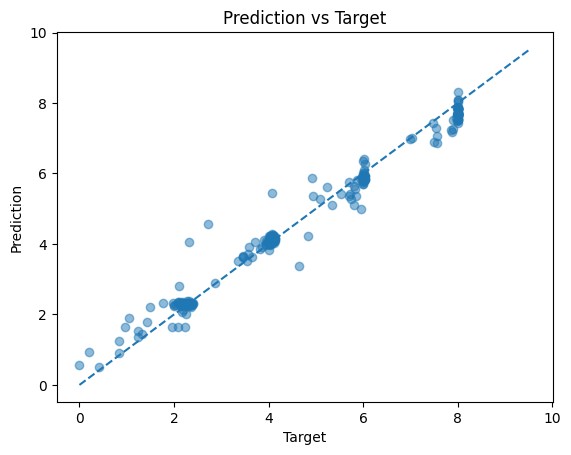

In [71]:
plt.figure()
plt.scatter(df["target"], df["prediction"], alpha=0.5)

# perfect prediction line
min_val = min(df["target"].min(), df["prediction"].min())
max_val = max(df["target"].max(), df["prediction"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Target")
plt.ylabel("Prediction")
plt.title("Prediction vs Target")
plt.show()

In [72]:
corr = df["target"].corr(df["prediction"])
print("Pearson correlation:", corr)

Pearson correlation: 0.9910664301502787


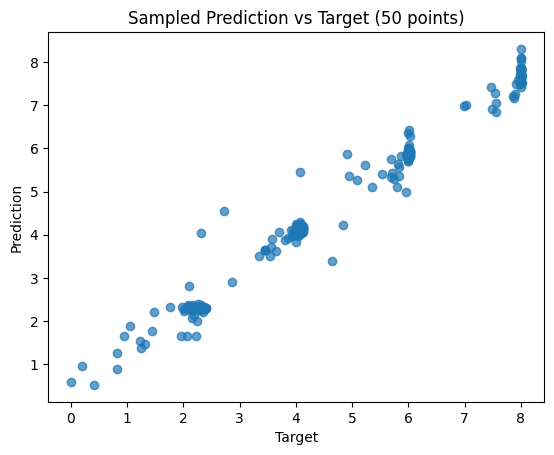

In [73]:
sample = df#.sample(300, random_state=42)

plt.figure()
plt.scatter(sample["target"], sample["prediction"], alpha=0.7)

# diagonal line
min_val = min(sample["target"].min(), sample["prediction"].min())
max_val = max(sample["target"].max(), sample["prediction"].max())
#plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Target")
plt.ylabel("Prediction")
plt.title("Sampled Prediction vs Target (50 points)")
plt.show()

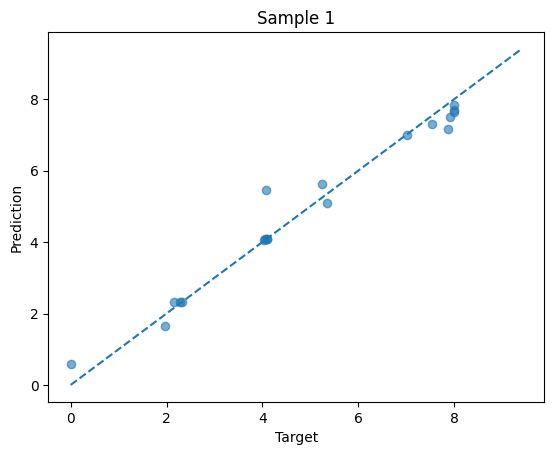

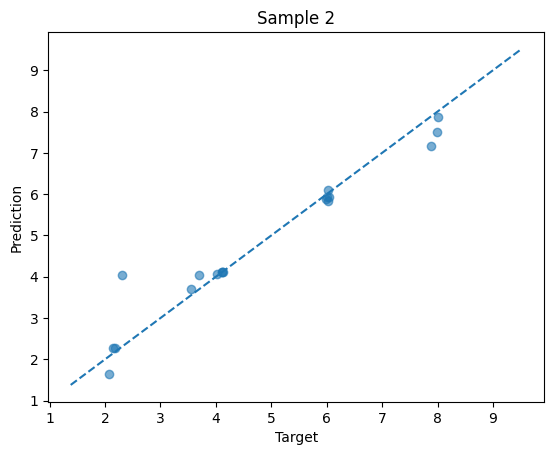

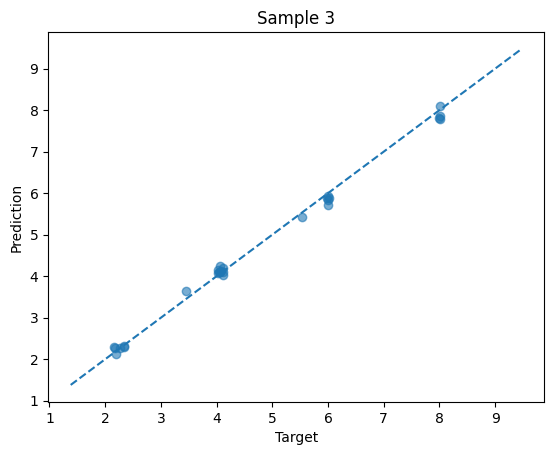

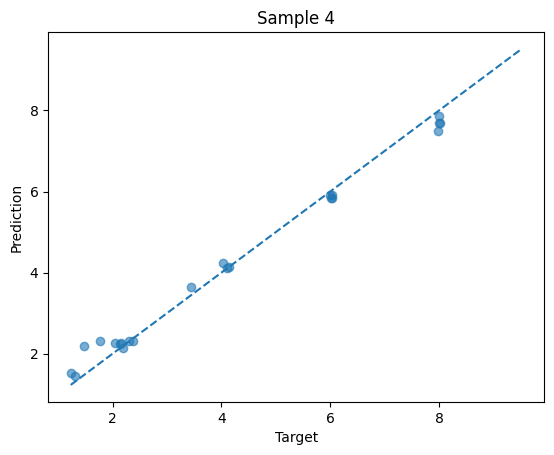

In [74]:
for i in range(4):
    sample = df.sample(30)

    plt.figure()
    plt.scatter(sample["target"], sample["prediction"], alpha=0.6)

    min_val = min(sample["target"].min(), sample["prediction"].min())
    max_val = max(sample["target"].max(), sample["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.title(f"Sample {i+1}")
    plt.xlabel("Target")
    plt.ylabel("Prediction")
    plt.show()

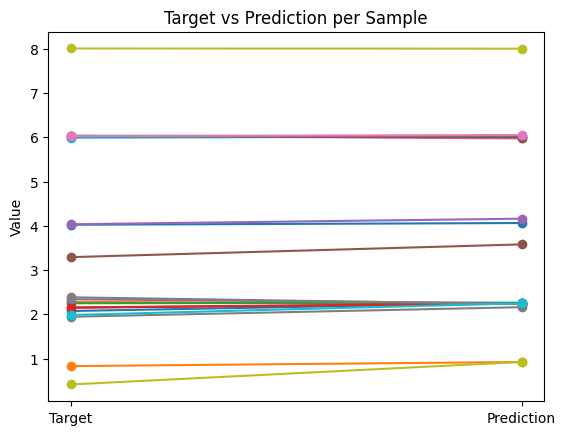

In [75]:
sample = df_clean.sample(20, random_state=0).reset_index(drop=True)

plt.figure()

for i in range(len(sample)):
    plt.plot([0, 1],
             [sample.loc[i, "target"], sample.loc[i, "prediction"]],
             marker="o")

plt.xticks([0, 1], ["Target", "Prediction"])
plt.ylabel("Value")
plt.title("Target vs Prediction per Sample")
plt.show()

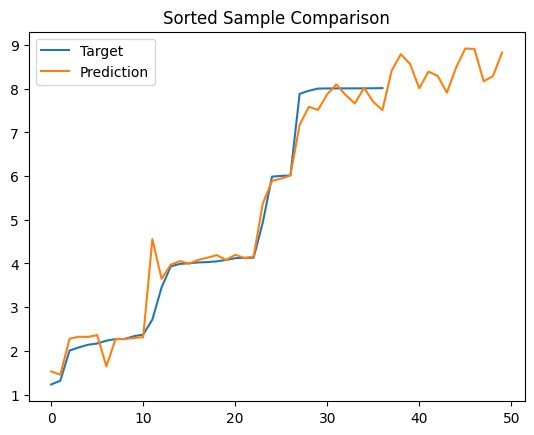

In [76]:
sample = df.sample(50).sort_values("target").reset_index(drop=True)

plt.figure()
plt.plot(sample["target"].values, label="Target")
plt.plot(sample["prediction"].values, label="Prediction")

plt.legend()
plt.title("Sorted Sample Comparison")
plt.show()

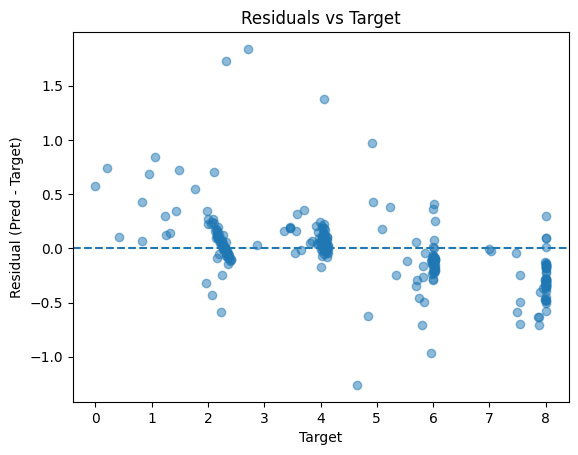

In [77]:
residuals = df["prediction"] - df["target"]

plt.figure()
plt.scatter(df["target"], residuals, alpha=0.5)
plt.axhline(0, linestyle="--")

plt.xlabel("Target")
plt.ylabel("Residual (Pred - Target)")
plt.title("Residuals vs Target")
plt.show()

In [78]:
from sklearn.metrics import r2_score
df_clean = df.dropna(subset=["target", "prediction"])
r2 = r2_score(df_clean["target"], df_clean["prediction"])
print("R²:", r2)

R²: 0.9782340974143595


In [79]:
import seaborn as sns
sns.kdeplot(x=df["target"], y=df["prediction"])



ModuleNotFoundError: No module named 'seaborn'